# Deep Learning Project: House Price Prediction (Regression)
## مقدمة عن المشروع
يهدف هذا الجزء من المشروع إلى بناء نموذج تعلم عميق (Deep Learning) لحل مشكلة انحدار (Regression)، حيث نقوم بالتنبؤ بأسعار العقارات المستمرة بناءً على خصائصها المختلفة. تم تطبيق كافة المتطلبات الهندسية من معالجة البيانات إلى حساب الانبعاثات الكربونية.

### prepared by:
#### Ahmed Essam Ismail 192100164
#### Mazen Mohsen 192100158
#### Daniel Ehab 192100133
#### Moomen Diaa 191800129

In [2]:
!pip install codecarbon

## 1. Data Preprocessing & Cleaning | معالجة وتجهيز البيانات
تعاملنا في هذه المرحلة مع البيانات لضمان كفاءة التدريب من خلال الخطوات التالية:
- **Filtering:** الاحتفاظ بالأعمدة الرقمية المؤثرة فقط لتجنب تشتت النموذج.
- **Data Cleaning (Propagation):** معالجة القيم المفقودة (Missing Values) باستخدام الـ Forward & Backward Fill للحفاظ على التسلسل المنطقي للبيانات.
- **Outliers Removal:** استخدام Z-score لاستبعاد القيم الشاذة التي قد تشوه توقعات الأسعار.
- **Scaling:** تقييس البيانات باستخدام `StandardScaler` لتسريع عملية الـ Convergence للنموذج.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from codecarbon import EmissionsTracker

# 1. قراءة البيانات
file_path = '/kaggle/input/datasets/dansbecker/melbourne-housing-snapshot/melb_data.csv' 
df = pd.read_csv(file_path)

# للسهولة وتجنب أخطاء النصوص، هنحتفظ بالأعمدة الرقمية فقط (زي عدد الغرف، المساحة، السعر)
df = df.select_dtypes(include=[np.number])

# 2. تنظيف البيانات (Data Cleaning & Propagation)
print(f"Missing values BEFORE cleaning:\n{df.isnull().sum().max()}") 
# نطبق الـ Propagation عشان نملى أي مساحات أو بيانات ناقصة
df = df.ffill().bfill() 
print(f"Missing values AFTER cleaning:\n{df.isnull().sum().max()}") 

# 3. تحديد المدخلات (X) والمخرجات (y)
target_column_name = 'Price'  # الهدف هنا هو توقع السعر
X = df.drop(target_column_name, axis=1)
y = df[target_column_name]

# 4. معالجة البيانات: إزالة القيم الشاذة (Outliers) 
z_scores = np.abs(stats.zscore(X))
X_clean = X[(z_scores < 3).all(axis=1)]
y_clean = y[X_clean.index]

# 5. تقسيم البيانات لتدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# 6. معالجة البيانات: التقييس (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Regression Data Preprocessing is Done! Training shape:", X_train_scaled.shape)

2026-05-09 17:06:29.350147: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778346389.783551      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778346389.899748      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778346390.925042      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778346390.925087      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778346390.925090      57 computation_placer.cc:177] computation placer alr

Missing values BEFORE cleaning:
6450
Missing values AFTER cleaning:
0
Regression Data Preprocessing is Done! Training shape: (9968, 12)


## 2. Model Architecture & Training | بناء وتدريب النموذج
تم تصميم معمارية النموذج لتناسب توقع قيم مستمرة (Continuous Values) كالتالي:
- **Hidden Layers:** طبقات بكثافة متدرجة (64، ثم 32 خلية) مع دالة التنشيط `ReLU`.
- **Output Layer:** خلية واحدة بدون دالة تنشيط (No Activation Function) لأن الهدف هو استخراج قيمة رقمية حقيقية (سعر العقار).
- **Loss Function:** تم استخدام الـ Mean Squared Error (MSE) لحساب الخطأ.
- **Sustainability:** تفعيل متتبع `CodeCarbon` لحساب استهلاك الطاقة وانبعاثات الكربون أثناء التدريب.

In [4]:
# 1. بناء المودل (Regression DL Model)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1) # بدون Activation
])

# بنستخدم mse (Mean Squared Error) كدالة الخسارة لأن ده انحدار
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# ========================================================
# 2. تشغيل متتبع الطاقة والانبعاثات الكربونية
# ========================================================
tracker = EmissionsTracker()
tracker.start()

# 3. تدريب المودل
history = model.fit(X_train_scaled, y_train, epochs=60, validation_split=0.2, verbose=0)

# إيقاف المتتبع وحفظ النتائج
emissions = tracker.stop()
energy_consumed = tracker.final_emissions_data.energy_consumed 

print("=" * 45)
print("Environmental Impact Metrics:")
print("=" * 45)
print(f"Energy Consumption: {energy_consumed:.6f} kWh")
print(f"Carbon Emission:    {emissions:.6f} kg CO2")
print("=" * 45)

# 4. حفظ المودل
model.save('regression_housing_model.h5')
print("\n[+] Model successfully saved as 'regression_housing_model.h5'")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778346430.697589      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778346430.704214      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
[codecarbon WARNING @ 17:07:12] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 17:07:12] [setup] RAM Tracking...
[codecarbon INFO @ 17:07:12] [setup] CPU Tracking...
[codecarbon WARNING

Environmental Impact Metrics:
Energy Consumption: 0.001493 kWh
Carbon Emission:    0.000676 kg CO2

[+] Model successfully saved as 'regression_housing_model.h5'


## 3. Learning Curves Analysis | تحليل منحنيات التعلم
مراقبة أداء النموذج أثناء مرحلة التدريب لضمان جودة التعلم:
- **Loss Curve (MSE):** للتأكد من انخفاض الخطأ بمرور الـ Epochs.
- **MAE Curve:** لمراقبة التحسن في متوسط الخطأ المطلق.
- **Overfitting Check:** التأكد من تقارب أداء النموذج بين بيانات التدريب (Train) وبيانات التحقق (Validation) وقدرته على التعميم.

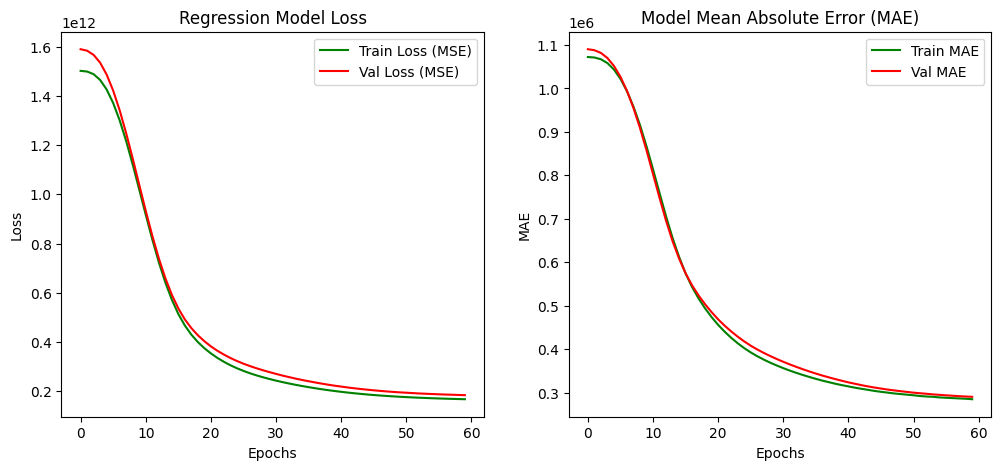

In [5]:
# رسم الـ Learning Curves
plt.figure(figsize=(12, 5))

# منحنى الـ Loss (MSE)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)', color='green')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)', color='red')
plt.title('Regression Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# منحنى الـ MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE', color='green')
plt.plot(history.history['val_mae'], label='Val MAE', color='red')
plt.title('Model Mean Absolute Error (MAE)')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()

plt.show()

## 4. Results, Metrics & Sustainability | النتائج النهائية والأثر البيئي
في هذه المرحلة الختامية، نختبر النموذج على بيانات جديدة كلياً (Test Set) ونستخرج مقاييس التقييم الهندسية المطلوبة:
- **Regression Metrics:** تقييم دقة التوقع باستخدام (MAE, MAPE, RMSE, R^2 Score).
- **Computational Efficiency:** حساب عدد العمليات الحسابية **FLOPS** لتقييم تعقيد النموذج.
- **Environmental Impact:** طباعة التقرير النهائي لاستهلاك الطاقة (kWh) والانبعاثات الكربونية (kg CO2) دعماً لمبادرات الذكاء الاصطناعي الأخضر.

In [6]:
# 1. التنبؤ واختبار المودل
y_pred = model.predict(X_test_scaled)

# 2. حساب مقاييس التقييم للانحدار
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # الجذر التربيعي للـ MSE
r2 = r2_score(y_test, y_pred)

print("-" * 40)
print("Evaluation Metrics (Regression Test):")
print("-" * 40)
print(f"MAE (Mean Absolute Error):      {mae:.4f}")
print(f"MAPE (Mean Absolute % Error):   {mape:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"R^2 Score:                      {r2:.4f}")
print("-" * 40)

# 3. حساب الـ FLOPS برمجياً باستخدام أوزان الطبقات
def calculate_flops(keras_model):
    total_flops = 0
    for layer in keras_model.layers:
        if isinstance(layer, tf.keras.layers.Dense):
            weights = layer.get_weights()
            if len(weights) > 0:
                input_dim = weights[0].shape[0]
                output_dim = weights[0].shape[1]
                layer_flops = 2 * input_dim * output_dim + output_dim
                total_flops += layer_flops
    return total_flops

flops_count = calculate_flops(model)
print(f"FLOPS (Calculated): {flops_count} operations")

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
----------------------------------------
Evaluation Metrics (Regression Test):
----------------------------------------
MAE (Mean Absolute Error):      297897.2052
MAPE (Mean Absolute % Error):   0.3156
RMSE (Root Mean Squared Error): 442864.0839
R^2 Score:                      0.4954
----------------------------------------
FLOPS (Calculated): 5793 operations
